In [33]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs

First let's do 1000 sims on the same FPI and Schedule seed. The main thing I'm looking at is the breakdown of when the higher FPI wins.

In [45]:
dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
}

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

In [68]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 1000

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

Coin flip! _________-----------_____________------------_______________-------- ['Dallas Cowboys', 'San Francisco 49ers']
Counter({'head to head': 3768, 'conference_record': 2219, 'common_games': 1016, 'division_record': 880, 'strength_of_victory': 352, 'strength_of_schedule': 9, 'Coin Flip!': 1})
Counter({'higher FPI won': 4123, 'lower FPI won': 4122})
                       playoff_percentage  Playoff_Percentage  FPI
Team                                                              
Jacksonville Jaguars                  966               0.966  4.1
Cincinatti Bengals                    927               0.927  4.0
Green Bay Packers                     862               0.862  2.8
Arizona Cardinals                     806               0.806  2.1
San Francisco 49ers                   775               0.775  1.9
Philadelphia Eagles                   731               0.731  1.0
Washington Commanders                 714               0.714  1.4
Denver Broncos                        677

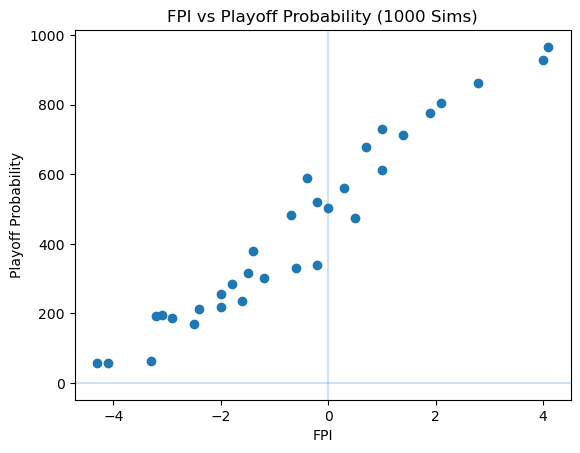

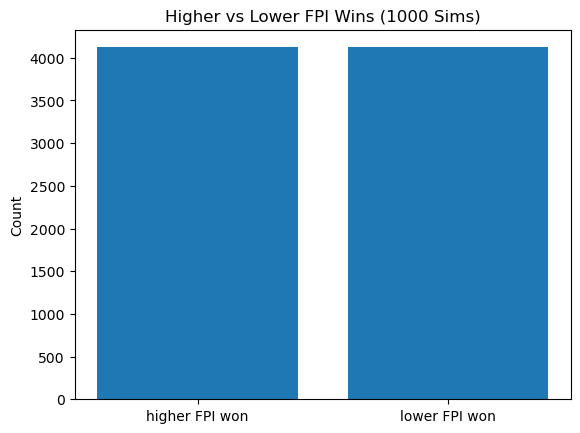

In [69]:
plt.scatter(field_prob_df["FPI"], field_prob_df["playoff_percentage"])

plt.xlabel("FPI")
plt.ylabel("Playoff Probability")
plt.title("FPI vs Playoff Probability (1000 Sims)")
plt.axhline(0.5,alpha = 0.2)
plt.axvline(0,alpha=0.2)

plt.show()

fpi_hist_df = (pd.Series(fpi_counts))

plt.figure()
plt.bar(fpi_hist_df.index, fpi_hist_df.values)
plt.ylabel("Count")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")
plt.show()

Now that we see that tiebreakers aren't really promoting the true "best" team, let's see what it looks like if we ran the same sim but with a new tiebreaker, which will be set in playoffs.py. This custom tiebreaker is simply point differential.

In [70]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 1000

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "custom") #tie_breaker is just point differential

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


print(tb_counts)
print(fpi_counts)
#print(field_count)

field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())

field_prob_df["Playoff_Percentage"] = field_prob_df["playoff_percentage"]/n
field_prob_df = field_prob_df.merge(df_seeded[["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")

print(field_prob_df)

Counter({'total_margin': 8245})
Counter({'higher FPI won': 5313, 'lower FPI won': 2932})
                       playoff_percentage  Playoff_Percentage  FPI
Team                                                              
Jacksonville Jaguars                  976               0.976  4.1
Cincinatti Bengals                    944               0.944  4.0
Green Bay Packers                     891               0.891  2.8
Arizona Cardinals                     837               0.837  2.1
San Francisco 49ers                   792               0.792  1.9
Philadelphia Eagles                   764               0.764  1.0
Washington Commanders                 735               0.735  1.4
Denver Broncos                        684               0.684  0.7
Carolina Panthers                     628               0.628  1.0
New York Jets                         619               0.619 -0.4
Baltimore Ravens                      586               0.586  0.3
New Orleans Saints                    53

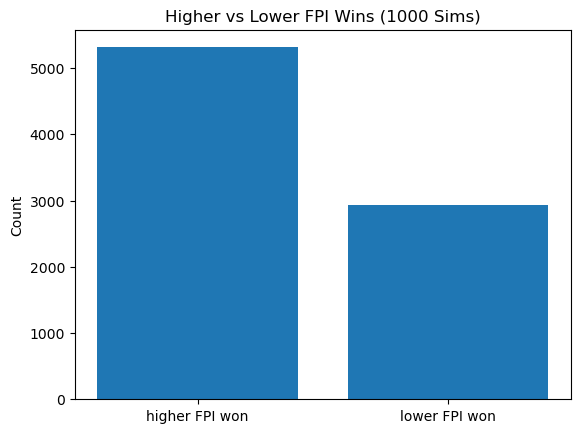

In [71]:
fpi_hist_df = (pd.Series(fpi_counts))

plt.figure()
plt.bar(fpi_hist_df.index, fpi_hist_df.values)
plt.ylabel("Count")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")
plt.show()

In [75]:
# How well do FPIs predict playoffs?
for year in range(2015, 2025):
    schedule = real_schedule_df(year)
    schedule["Home"] = schedule["Home"].replace(corrected_teams)
    schedule["Away"] = schedule["Away"].replace(corrected_teams)

    dfs[year]["Team"] = dfs[year]["Team"].replace(corrected_teams).copy()
    field_count = Counter()
    n = 300
    for sim_seed in range(1, n + 1):
        results, standings = simulate_season(dfs[year],schedule,seed = sim_seed)
        field, tiebreakers, fpi = playoff_field(standings,results)
        field_count.update(Counter(field["Team"]))
    
    # load schedules
    sched = nfl.load_schedules([year]).to_pandas()
    
    # keep only playoff games
    playoffs = sched[sched["game_type"] != "REG"]
    
    # get unique teams that played in playoffs
    playoff_teams = set(playoffs["home_team"]).union(set(playoffs["away_team"]))
    #print(playoff_teams)
    
    field_prob_df = (pd.Series(field_count).sort_values(ascending=False).rename("playoff_percentage").to_frame())
    
    field_prob_df["playoff_percentage"] = field_prob_df["playoff_percentage"]/n
    field_prob_df = field_prob_df.merge(dfs[year][["Team", "FPI"]],left_index=True,right_on="Team",how="left").set_index("Team")
    field_prob_df["abbr"] = field_prob_df.index.map(team_to_abbr)
    field_prob_df["Made_Playoffs"] = field_prob_df["abbr"].isin(playoff_teams).astype(int)
    field_prob_df["Rank"] = field_prob_df["playoff_percentage"].rank(ascending=False, method="first").astype(int)

    playoff_only_df = (field_prob_df[field_prob_df["Made_Playoffs"] == 1].sort_values("Rank"))
    k = field_prob_df["Made_Playoffs"].sum()
    ideal_mean = (1 + k) / 2
    actual_mean = field_prob_df[field_prob_df["Made_Playoffs"] == 1]["Rank"].mean()
    accuracy_score = ideal_mean / actual_mean
    
    print(year)
    print(playoff_only_df)
    print(accuracy_score)
    
    #print(field_prob_df)

2015
                       playoff_percentage  FPI abbr  Made_Playoffs  Rank
Team                                                                    
Carolina Panthers                1.000000  7.9  CAR              1     1
Seattle Seahawks                 1.000000  8.8  SEA              1     2
Arizona Cardinals                0.996667  8.3  ARI              1     3
New England Patriots             0.976667  7.2   NE              1     4
Pittsburgh Steelers              0.950000  7.1  PIT              1     5
Kansas City Chiefs               0.923333  6.8   KC              1     6
Denver Broncos                   0.880000  5.9  DEN              1     7
Green Bay Packers                0.823333  3.6   GB              1     9
Minnesota Vikings                0.756667  2.8  MIN              1    10
Houston Texans                   0.666667 -0.2  HOU              1    11
Cincinnati Bengals               0.663333  4.1  CIN              1    12
Washington Commanders            0.336667 -2.8

Coin flip! _________-----------_____________------------_______________-------- ['New Orleans Saints', 'Tampa Bay Buccaneers']


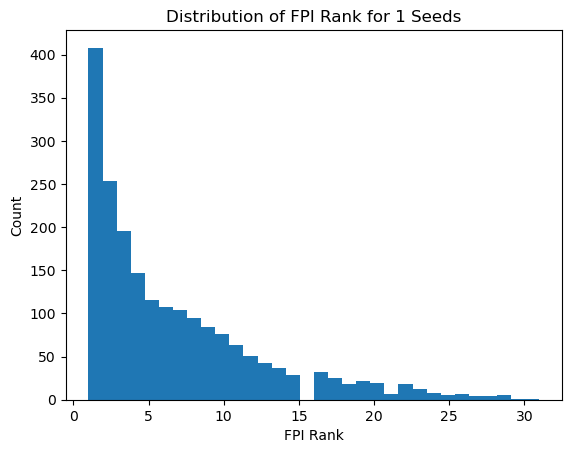

In [65]:
# Look at the #1 seed and see where they rank by FPI (Both NFC & AFC), generate histogram
one_seed_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    one_seeds = field[field["Seed"] == 1]["Team"]

    # grab the rows for the 1 seeds
    one_seed_rows = standings_df.loc[standings_df["Team"].isin(one_seeds),["Team", "FPI_Rank"]].copy()

    one_seed_ranks.append(one_seed_rows) # store results

# combine all simulations
one_seed_ranks_df = pd.concat(one_seed_ranks, ignore_index=True)

plt.hist(one_seed_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for 1 Seeds")
plt.show()

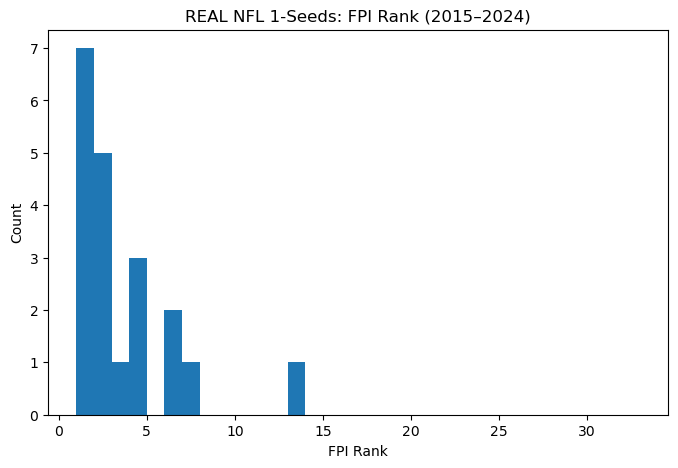

In [64]:
one_seed_fpi_history = []

for year in range(2015, 2025):
    results, standings = build_real_season_dfs(year)
    # replace all teams
    results["Home"]   = results["Home"].replace(corrected_teams)
    results["Away"]   = results["Away"].replace(corrected_teams)
    results["Winner"] = results["Winner"].replace(corrected_teams)
    results["Loser"]  = results["Loser"].replace(corrected_teams)
    standings["Team"] = standings["Team"].replace(corrected_teams)

    # replace FPI with CSV version
    standings = standings.drop(columns=["FPI"])
    standings = standings.merge(dfs[year][["Team", "FPI"]], on="Team", how="left")
    standings["FPI_Rank"] = standings["FPI"].rank(method="min", ascending=False).astype(int)
    
    field, tiebreakers, fpi_winners = playoff_field(standings, results)
    
    # grab the 1 seeds
    one_seeds = field.loc[field["Seed"] == 1, "Team"]

    rows = standings.loc[standings["Team"].isin(one_seeds), ["Team", "Conference", "FPI", "FPI_Rank"]].copy()
    rows["Year"] = year
    one_seed_fpi_history.append(rows)

one_seed_fpi_history_df = pd.concat(one_seed_fpi_history, ignore_index=True)
plt.figure(figsize=(8,5))
plt.hist(one_seed_fpi_history_df["FPI_Rank"], bins=range(1,34))
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("REAL NFL 1-Seeds: FPI Rank (2015–2024)")
plt.show()

Coin flip! _________-----------_____________------------_______________-------- ['New Orleans Saints', 'Tampa Bay Buccaneers']

All Super Bowl winner FPI ranks:
                     Team  FPI_Rank
0          Houston Texans         7
1        Baltimore Ravens         3
2    Jacksonville Jaguars         1
3           Detroit Lions         2
4       Arizona Cardinals         4
..                    ...       ...
995  Los Angeles Chargers         3
996       New York Giants         4
997         Buffalo Bills        12
998         New York Jets         8
999   Philadelphia Eagles         1

[1000 rows x 2 columns]


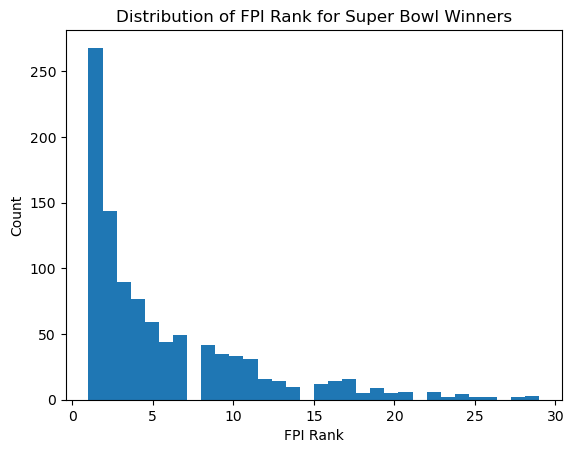

In [15]:
# How often does the best team win the Super Bowl
sb_winner_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)

    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    # simulate playoffs and get super bowl champion
    playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, sigma=9, home_field=2, seed=sim_seed)

    # grab champion's FPI rank
    sb_row = standings_df.loc[standings_df["Team"] == sb_winner,["Team", "FPI_Rank"]].copy()

    # store results
    sb_winner_ranks.append(sb_row)

# combine all simulations
sb_winner_ranks_df = pd.concat(sb_winner_ranks, ignore_index=True)

plt.hist(sb_winner_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for Super Bowl Winners")
plt.show()


All Super Bowl winner FPI ranks:
                     Team  FPI_Rank
0     Pittsburgh Steelers        16
1        Baltimore Ravens         3
2    Jacksonville Jaguars         1
3           Detroit Lions         2
4     San Francisco 49ers         5
..                    ...       ...
995  Los Angeles Chargers         3
996    New Orleans Saints         9
997  Jacksonville Jaguars        13
998         New York Jets         8
999         Detroit Lions         2

[1000 rows x 2 columns]


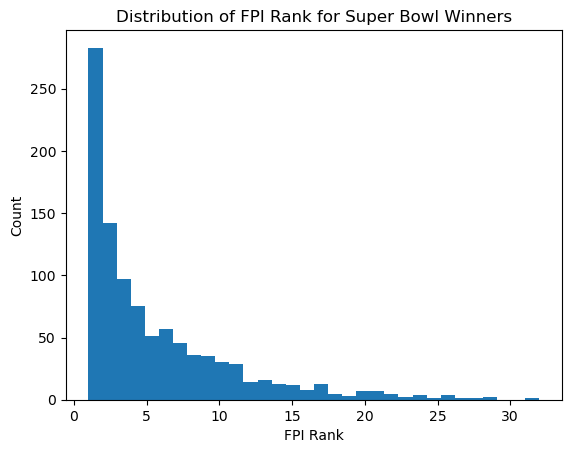

In [14]:
# How often does the best team win the Super Bowl (custom tiebreakers)
sb_winner_ranks = []

n = 1000
for sim_seed in range(1, n + 1):

    df_seeded = make_random_fpi(df, mean=-0.016, std=2.5, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)

    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "custom")

    # simulate playoffs and get champion
    playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, sigma=9, home_field=2, seed=sim_seed)

    # grab champion's FPI rank
    sb_row = standings_df.loc[standings_df["Team"] == sb_winner,["Team", "FPI_Rank"]].copy()

    # store results
    sb_winner_ranks.append(sb_row)

# combine all simulations
sb_winner_ranks_df = pd.concat(sb_winner_ranks, ignore_index=True)

plt.hist(sb_winner_ranks_df["FPI_Rank"], bins=32)
plt.xlabel("FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of FPI Rank for Super Bowl Winners")
plt.show()